# Quality toolbox

In [1]:
# Import library needed
#import functions
import numpy as np
import matplotlib.pyplot as plt

from NEUREQUA import *

from NEUREQUA import cognitive_module as cog 
from NEUREQUA import quality_module as quality

## Load data and parameters

In [2]:
# Parameters of the session you analyze

# Name or number of the subject you analyze
sub = 'sub-118'
# Name of the session you analyze
sess = 'screening1'

In [3]:
# Path to data - This is the only thing you have to change to run the script


# Path where your micro data are stored (.dat, .medd, .nsX, .ncs)
dataFolder=r'F:\Screening\database\sub-118\sess-1\ncs' 

# Path where you want to store figures and results
saveFolder=r'F:\Screening\results\sub-118\screening1\quality_data/'

# path to excel file for the RMS tracking, only one excel is used per patient, all RMS data for the SEEG will be trancked on a single file

trackingtbl ='F:/Screening/results/Quality/sub-118-2-tracking.xlsx'


In [4]:
# Load data 
# Give the path folder where the ncs files of micro-electrodes are stored
raw_data, data = quality.load_raw_data(dataFolder,dtype='ncs',length=5)

Checking files in F:\Screening\database\sub-118\sess-1\ncs
Ignoring .ncs files:

Checking for temporal discontinuities in Neo data segments.
No discontinuities detected.


In [5]:
# Determine parameters from the recording
sr = int(raw_data.info['sfreq'])
print("Your recording has a sampling rate of: " + str(sr) +" Hz")

Your recording has a sampling rate of: 32768 Hz


In [6]:
duration_min  = int(raw_data.__len__()/sr/60)

print("L'enregistrement a duré : "+str(duration_min)+" minutes")

L'enregistrement a duré : 5 minutes


In [7]:
# Display the name of your electrodes

chRegions = np.array(raw_data.ch_names)
print(chRegions)

['da1' 'da2' 'da3' 'da4' 'da5' 'da6' 'da7' 'da8' 'dtp1' 'dtp2' 'dtp3'
 'dtp4' 'dtp5' 'dtp6' 'dtp7' 'dtp8' 'vb1' 'vb2' 'vb3' 'vb4' 'vb5' 'vb6'
 'vb7' 'vb8' 'vof1' 'vof2' 'vof3' 'vof4' 'vof5' 'vof6' 'vof7' 'vof8'
 'vor1' 'vor2' 'vor3' 'vor4' 'vor5' 'vor6' 'vor7' 'vor8' 'vot1' 'vot10'
 'vot11' 'vot12' 'vot2' 'vot3' 'vot4' 'vot5' 'vot6' 'vot7' 'vot8' 'vot9']


In [8]:
# Re-order channels and data if there is more than two tetrode on a shaft
chRegions, data = quality.reorder_data(chRegions,data)

print(chRegions)

['da1' 'da2' 'da3' 'da4' 'da5' 'da6' 'da7' 'da8' 'dtp1' 'dtp2' 'dtp3'
 'dtp4' 'dtp5' 'dtp6' 'dtp7' 'dtp8' 'vb1' 'vb2' 'vb3' 'vb4' 'vb5' 'vb6'
 'vb7' 'vb8' 'vof1' 'vof2' 'vof3' 'vof4' 'vof5' 'vof6' 'vof7' 'vof8'
 'vor1' 'vor2' 'vor3' 'vor4' 'vor5' 'vor6' 'vor7' 'vor8' 'vot1' 'vot2'
 'vot3' 'vot4' 'vot5' 'vot6' 'vot7' 'vot8' 'vot9' 'vot10' 'vot11' 'vot12']


## Quality analysis of the signal

In [9]:
# Get the power spectrum for each channel

p_spectrum = []
for iCh in range(data.shape[0]):
    pxx, f_plot = quality.p_welch(data[iCh],sr=sr,sr_down=4,fr_low=1,fr_high=600)

    p_spectrum.append(pxx)
    


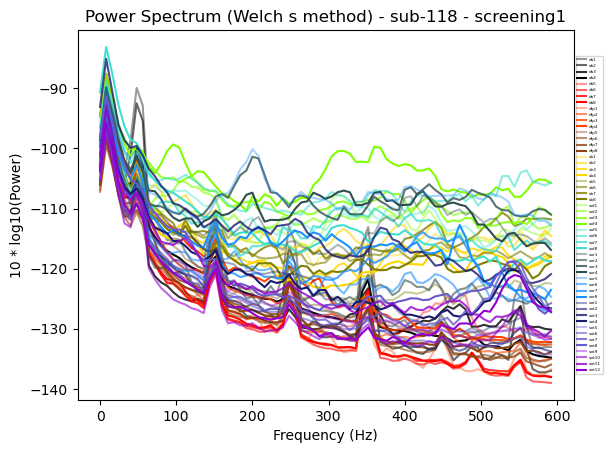

In [10]:
# Plot the results of PSD for each channel
quality.plot_all_chan(f_plot,nCh=len(chRegions),chRegs=chRegions,psd=p_spectrum,bsnm=sub,session=str(sess),probe_type='Dixi',saveFolder=saveFolder)

In [11]:
# Get the level of noise of the recording for each channel

for iCh in range(data.shape[0]):
    quality.plot_noise(data[iCh],sr=int(sr),num_channel=iCh,name_channels=chRegions[iCh],path=saveFolder)



In [12]:
# get the RMS for each channel 
#prep RMS tracking excel file 

quality.tblprep(trackingtbl,chRegions,sub,sess)


for iCh in range(data.shape[0]):
    quality.rms_signal(data[iCh],trackingtbl,chRegions[iCh],sub,sess)
    quality.rms_signal_filtered (data[iCh],trackingtbl,chRegions[iCh],sub,sess,fr_low=300,fr_high=3000,sr=sr) 


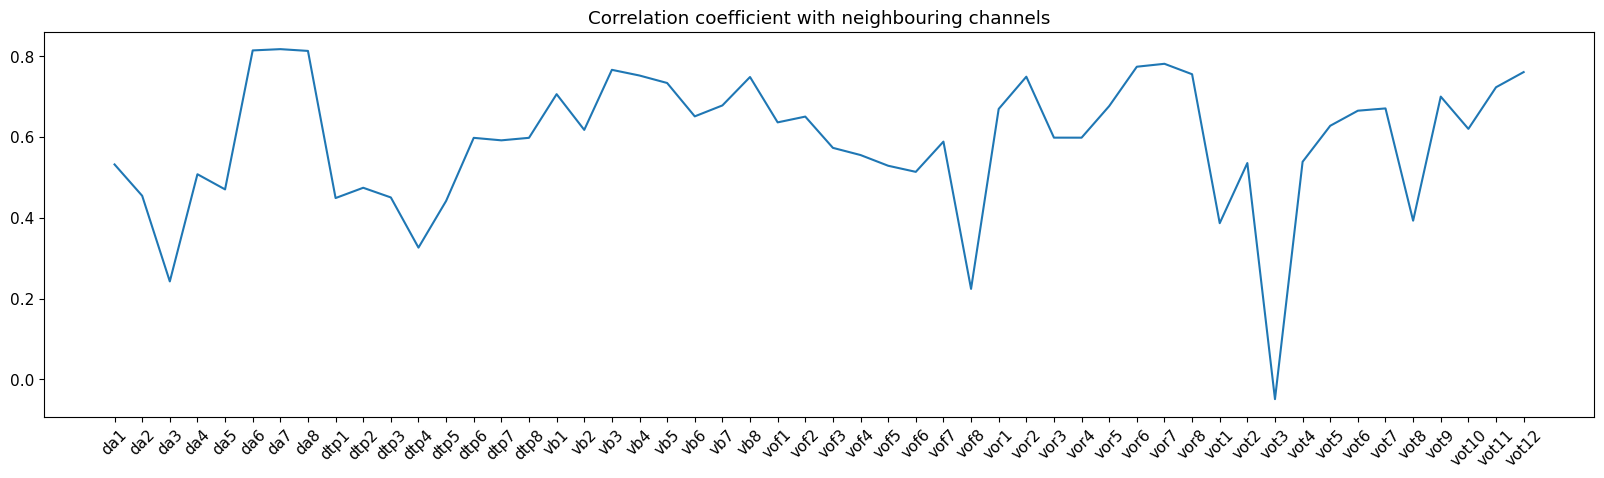

In [13]:
# Compute correlation between neighbouring channels

quality.correlation_coefficient(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

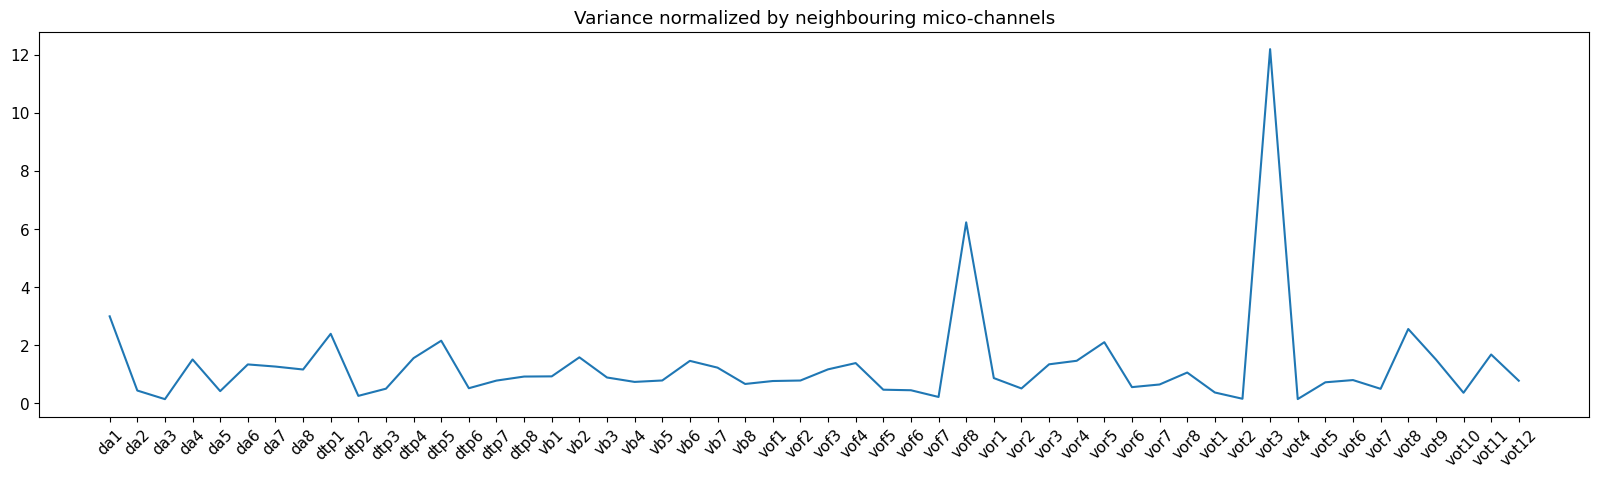

In [14]:
# Compute variance normalized by variance of neighbouring channels
quality.variance_normalized(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

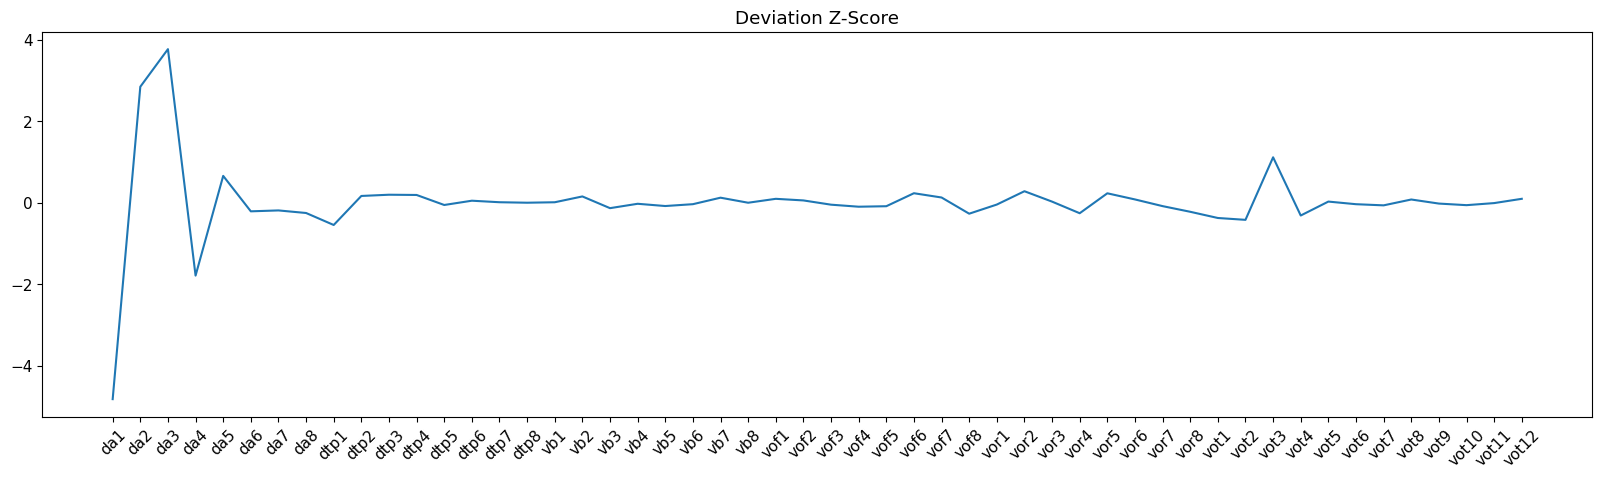

In [15]:
quality.deviation(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

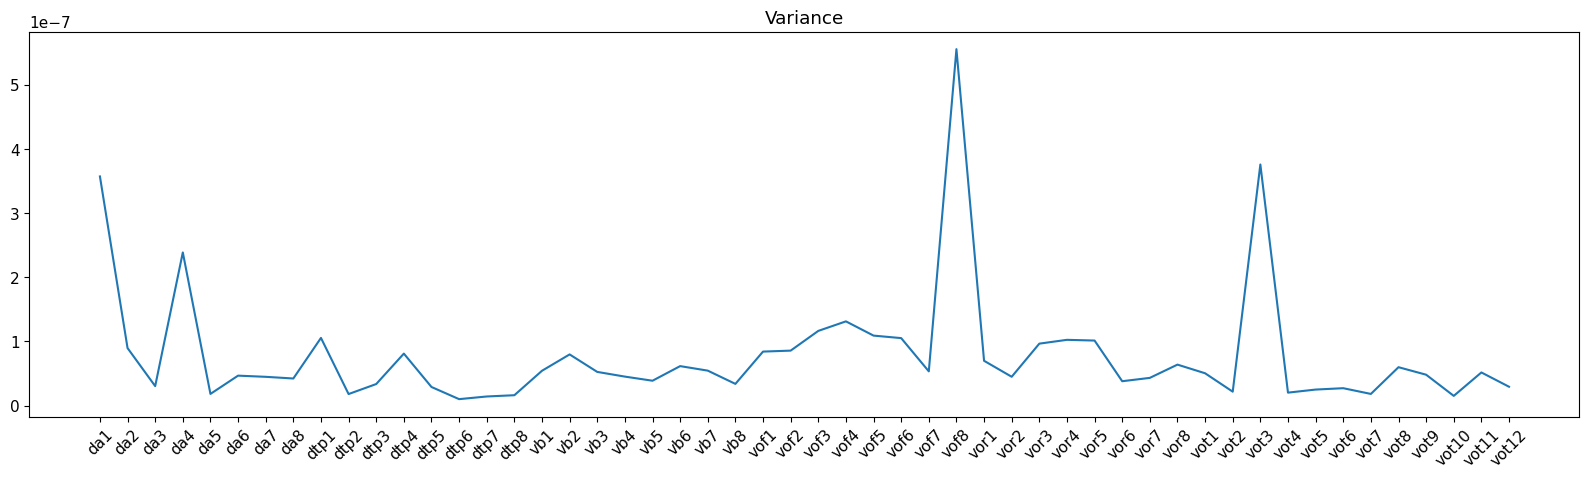

In [16]:
quality.variance(data,chRegions,saveFolder,trackingtbl,sub,sess)

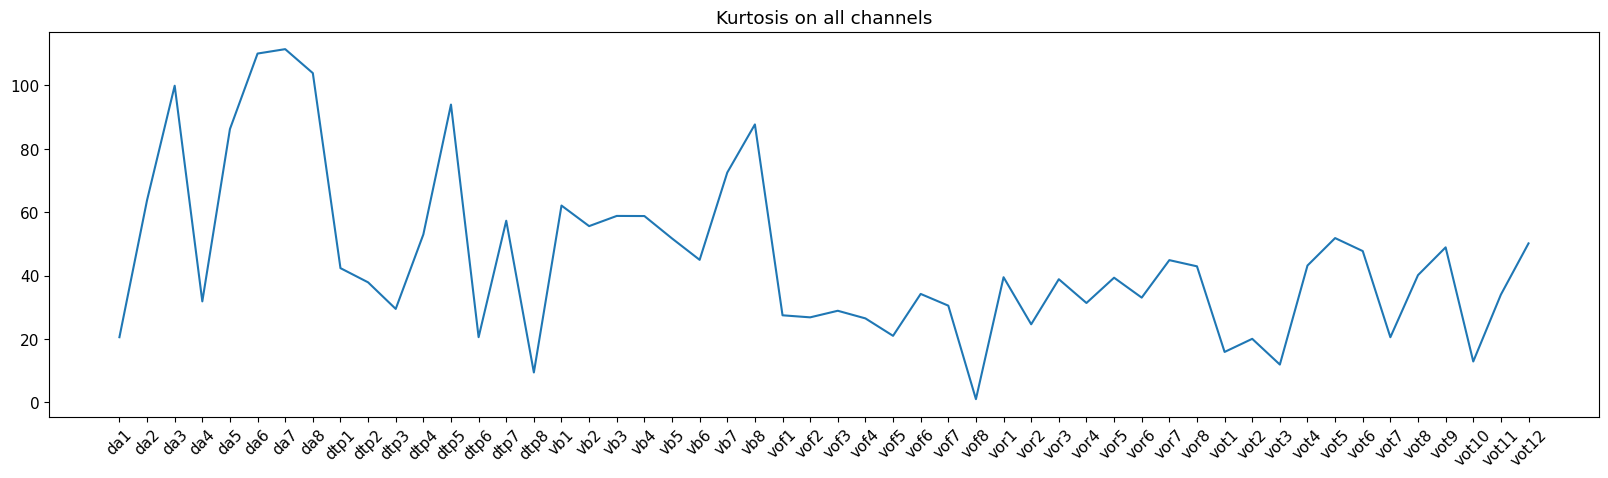

In [17]:
quality.kurtosis(data,chRegions,saveFolder,trackingtbl,sub,sess)

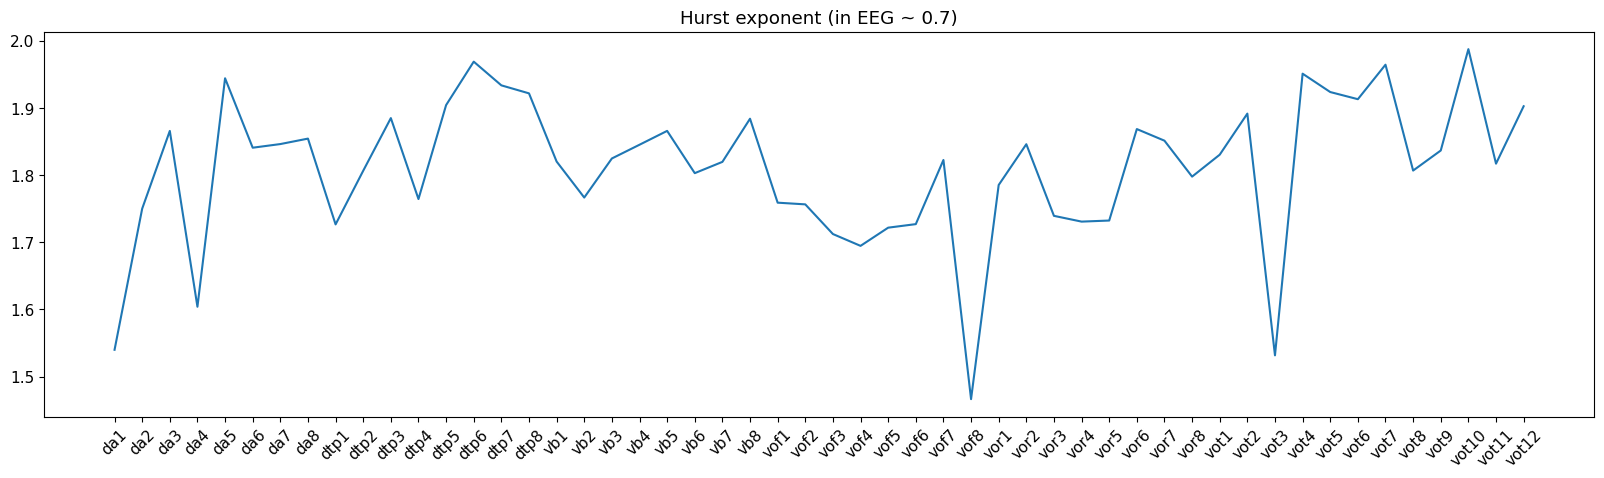

In [18]:
quality.hurst_component(data,chRegions,saveFolder,trackingtbl,sub,sess)

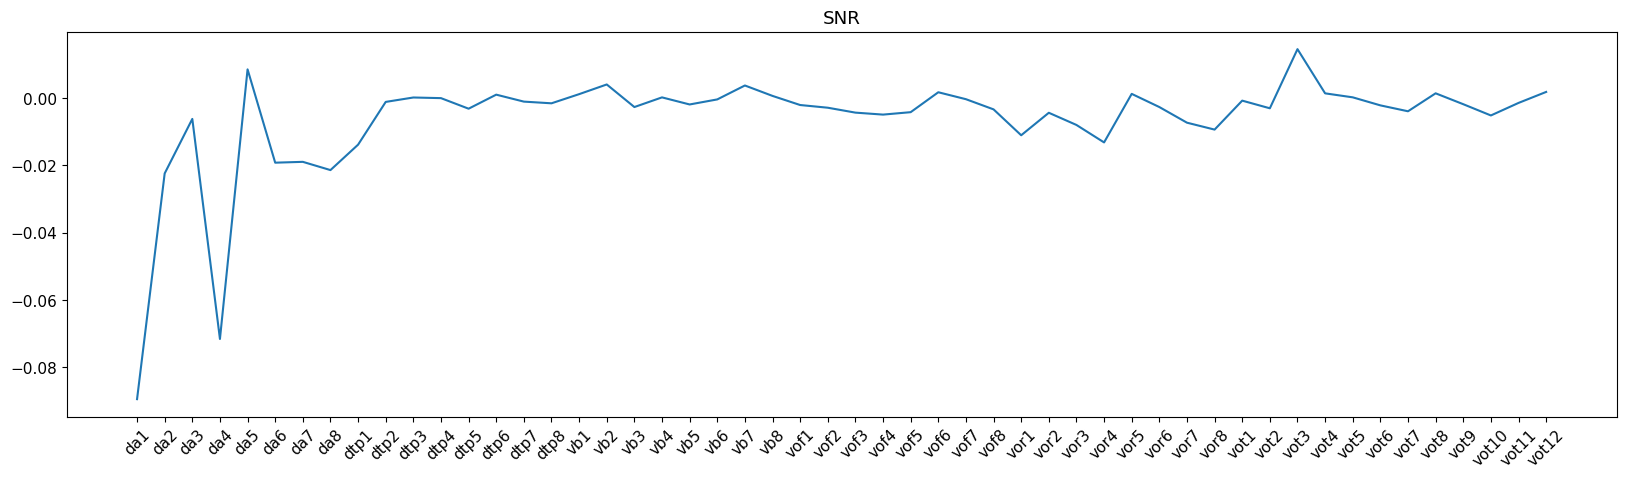

In [19]:
SNR = quality.signaltonoise(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [30]:
# Test on artefacts

from NEUREQUA import artefact_detections

tetInds = test 

# Movement artefacts
badWins_movement = artefact_detections.detect_movement_artifacts(chTraces=data,chGoodInds=list(range(len(chRegions))),
                                                                tetInds=tetInds,verbose=False,SR=32768)


# Detect subtle artefacts
badWins_subtle = artefact_detections.detect_subtle_artifacts(chTraces=data,chGoodInds=np.array(list(range(len(chRegions)))),
                                                            tetInds= tetInds,chRegs=chRegions,SR=32768,verbose=False)

# Step 3: Merge detected windows using intersection
badWins_final = artefact_detections.get_timeWinsIntersect(badWins_movement, badWins_subtle, data.shape[1])


# Step 4: Print percentage of artefacted signal
artefact_detections.ratio_artefact(data,badWins_final,trackingtbl,sub,sess)

Your recording contains: 15.518481901196097 % of artefacts


In [29]:
test = list()
count_tetrode = 0
for iTetrode in range(int(data.shape[0]/4)):
    num_canalTetrode = (iTetrode*4,iTetrode*4+1,iTetrode*4+2,iTetrode*4+3)

    test.append(num_canalTetrode)


print(list(test))

[(0, 1, 2, 3), (4, 5, 6, 7), (8, 9, 10, 11), (12, 13, 14, 15), (16, 17, 18, 19), (20, 21, 22, 23), (24, 25, 26, 27), (28, 29, 30, 31), (32, 33, 34, 35), (36, 37, 38, 39), (40, 41, 42, 43), (44, 45, 46, 47), (48, 49, 50, 51)]


In [25]:
iTetrode

13.0

# Cognitive analyses of experiment

In [ ]:
# Create epoch objects
epoch = cog.create_epoch(dataFolder,t_min=-1,t_max=1)

NameError: name 'dataFolder' is not defined

In [ ]:
# This step is really long, if you have your own method quicker you should use it
epoch = epoch.get_data()
np.save(r'F:\Screening\database\sub-123\sess-1\epoch/epoch_micro.npy',epoch)

Loading data for 808 events and 65537 original time points ...
137 bad epochs dropped


In [24]:
# If you already created your epoch numpy file load it
epoch_data = np.load(r'F:\Screening\database\sub-123\sess-1\epoch/epoch_micro.npy')

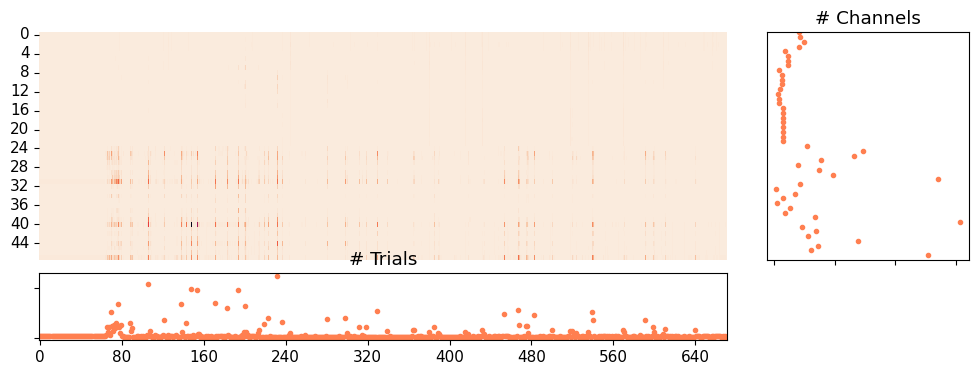

In [26]:
cog.plot_artefact_map(epoch_data=epoch_data,path='C:/Users/dornier/PhD/Quality_Data/')